# Bagging Classifier: Deep Dive
## Loan Default Prediction (HMEQ Dataset)

*Part of the [ML Model Comparison](../loan_default_tradeoff_matrix.html) series on bitterscientist.com*

This notebook covers:
1. Bootstrap aggregating: the intuition and the math
2. Variance reduction via averaging and bias-variance decomposition
3. Out-of-bag (OOB) error estimation
4. Comparison with Random Forest (all features vs random subset per split)
5. Worked examples using actual HMEQ data
6. Model training with hyperparameter tuning
7. Diagnostic visualizations (OOB error, feature importance, individual tree variance)
8. Results interpretation

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, ".")
from shared_utils import *

# Additional imports
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

MODEL_NAME = "Bagging Classifier"
MODEL_SLUG = "bagging"

# Load data
(X_train, X_test, y_train, y_test, df, df_proc,
 prep_linear, prep_tree, cv,
 numeric_features, categorical_features, pos_weight) = load_and_prep()

Dataset loaded: 5960 rows, 13 columns
Default rate: 19.95%
Train: 4470 | Test: 1490
Numeric features: 15 | Categorical: 2
Positive class weight: 4.01


---
## 2. The Math Behind Bagging (Bootstrap Aggregating)

### 2.1 The Core Idea

**Bagging** (Bootstrap Aggregating) is an ensemble method that reduces variance by training multiple estimators on random samples of the training data and averaging their predictions.

The key insight: if we had access to multiple independent samples from the population, we could train a separate model on each and average their predictions. This averaging would reduce variance without increasing bias, provided the samples are truly independent. In practice, we only have one dataset, so bagging approximates this by drawing multiple samples **with replacement** (bootstrap samples) from the original training data.

### 2.2 The Bootstrap Sampling Process

Given training data $\{(x_1, y_1), \ldots, (x_n, y_n)\}$, bootstrap sampling works as follows:

1. For the $m$-th bootstrap replicate (where $m = 1, 2, \ldots, M$):
   - **Draw $n$ samples with replacement** from the original training set
   - This creates a dataset $D^{(m)}$ of size $n$ (same as original, but with duplicates and omissions)
   - **Train an estimator** $\hat{f}^{(m)}$ on $D^{(m)}$

2. **Aggregate predictions**:
   - For regression: $\hat{f}_{\text{bagging}}(x) = \frac{1}{M} \sum_{m=1}^{M} \hat{f}^{(m)}(x)$
   - For classification: $\hat{f}_{\text{bagging}}(x) = \text{argmax}_k \frac{1}{M} \sum_{m=1}^{M} \mathbb{1}[\hat{f}^{(m)}(x) = k]$ (majority vote)
   - For probability: $\hat{p}_k(x) = \frac{1}{M} \sum_{m=1}^{M} P(\hat{f}^{(m)}(x) = k)$ (average probabilities)

### 2.3 Why Averaging Reduces Variance

Suppose we have $M$ independent estimators with variance $\sigma^2$. If the estimators are independent, the variance of their average is:

$$\text{Var}\left[\frac{1}{M} \sum_{m=1}^{M} \hat{f}^{(m)}\right] = \frac{1}{M^2} \sum_{m=1}^{M} \text{Var}[\hat{f}^{(m)}] = \frac{1}{M^2} \cdot M \sigma^2 = \frac{\sigma^2}{M}$$

The variance is **reduced by a factor of $M$** (the number of estimators). This is the fundamental appeal of bagging.

In practice, bootstrap samples are not independent (they all come from the same data), so the variance reduction is less than the theoretical maximum. A rule of thumb: bagging reduces variance by a factor of approximately $\sqrt{M}$ to $M$, depending on the base estimator and data.

### 2.4 Bias-Variance Decomposition for Ensembles

The mean squared error can be decomposed as:

$$\text{MSE}[\hat{f}] = \text{Bias}[\hat{f}]^2 + \text{Var}[\hat{f}] + \sigma_\epsilon^2$$

where $\sigma_\epsilon^2$ is the irreducible error.

For bagging:
- **Bias:** Approximately unchanged (or slightly decreased). If each $\hat{f}^{(m)}$ is unbiased, then $\mathbb{E}[\hat{f}_{\text{bagging}}] \approx \mathbb{E}[\hat{f}^{(m)}]$.
- **Variance:** Reduced significantly by averaging (as shown above).

This makes bagging particularly powerful for **high-variance, low-bias models** like decision trees. It is less effective for models that are already biased (e.g., linear models with insufficient feature engineering).

### 2.5 Out-of-Bag (OOB) Error Estimation

A clever property of bagging with bootstrap samples: each training sample is left out of approximately $\left(1 - \frac{1}{n}\right)^n \approx e^{-1} \approx 0.368$ (36.8%) of the bootstrap samples.

We can use these **out-of-bag samples** to estimate test error without a separate validation set:

1. For each training sample $i$, identify all bootstrap samples that **did not include** sample $i$
2. Average predictions from those estimators (they have never seen sample $i$ during training)
3. Compare to the true label $y_i$
4. Compute error across all out-of-bag predictions

OOB error estimates test error surprisingly well and is **nearly unbiased** (similar to leave-one-out cross-validation but much cheaper computationally).

### 2.6 Bagging vs Random Forest

| Aspect | Bagging | Random Forest |
|--------|---------|---------------|
| Base estimator | Any model (usually trees) | Decision trees |
| Sampling strategy | Bootstrap all features | Bootstrap samples AND random feature subset per split |
| Feature diversity | Low (same features at each node of each tree) | High (each split considers only ~√p features) |
| Variance reduction | Moderate (~√M to M) | High (additional randomness in features) |
| Bias | Unchanged | Slightly increased |
| Interpretability | Per-tree interpretability still exists | Even harder to interpret due to feature randomization |
| Use case | Baseline ensemble; works with any base estimator | More powerful; usually preferred for trees |

When you use `BaggingClassifier` with `DecisionTreeClassifier` as the base estimator, you get **Bagging**. When you use Random Forest, you get the additional feature randomization that makes it more powerful.

---
## 3. Visualizing Bootstrap Samples

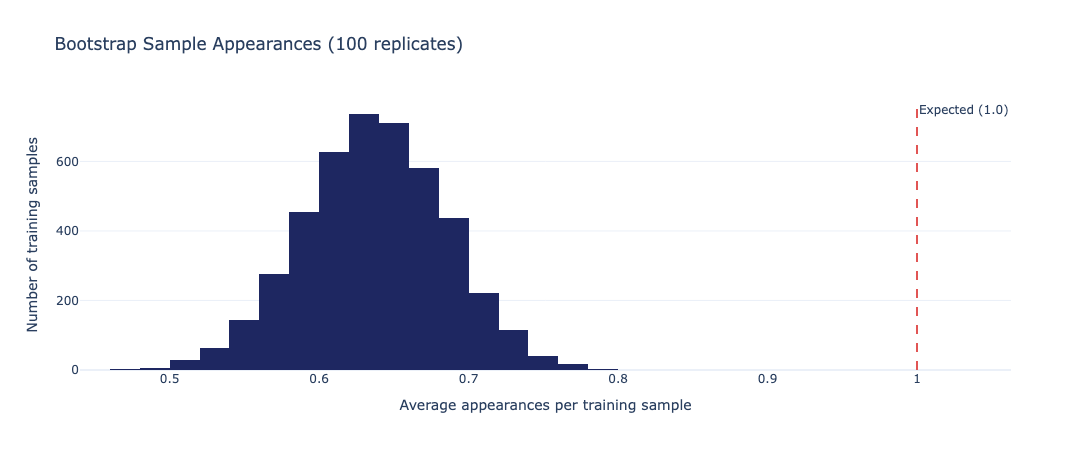

  Saved: outputs/bagging/bootstrap_distribution.html
Average sample appearances per bootstrap: 0.6318
Average OOB rate per sample: 0.3682 (expected ~0.368)


In [2]:
# Demonstrate bootstrap sampling
np.random.seed(RANDOM_STATE)
n_samples = len(y_train)
n_bootstraps = 100

# Track how many times each sample appears in each bootstrap
appearance_counts = np.zeros((n_samples, n_bootstraps))
oob_counts = np.zeros(n_samples)

for b in range(n_bootstraps):
    # Draw bootstrap sample
    boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    appearance_counts[boot_indices, b] += 1
    
    # Count samples NOT in this bootstrap (out-of-bag)
    in_bag = np.zeros(n_samples, dtype=bool)
    in_bag[boot_indices] = True
    oob_counts[~in_bag] += 1

# Plot: how many times each sample appears across all bootstraps
avg_appearances = appearance_counts.mean(axis=1)
avg_oob = oob_counts / n_bootstraps

fig = go.Figure()
fig.add_trace(go.Histogram(
    x=avg_appearances, nbinsx=20,
    name="Avg appearances per bootstrap",
    marker_color=COLORS["navy"],
))
fig.add_vline(x=1.0, line_dash="dash", line_color=COLORS["red"],
              annotation_text="Expected (1.0)")
fig.update_layout(
    title=f"Bootstrap Sample Appearances ({n_bootstraps} replicates)",
    xaxis_title="Average appearances per training sample",
    yaxis_title="Number of training samples",
    height=450, width=700,
)
fig.show()
save_chart(fig, MODEL_SLUG, "bootstrap_distribution")

print(f"Average sample appearances per bootstrap: {avg_appearances.mean():.4f}")
print(f"Average OOB rate per sample: {avg_oob.mean():.4f} (expected ~0.368)")

---
## 4. Worked Example: Variance Reduction

In [3]:
# Train a single decision tree and a bagging ensemble on HMEQ
# Compare their variance across bootstrap samples

print("="*70)
print("WORKED EXAMPLE: Variance Reduction via Bagging")
print("="*70)

# Single decision tree
single_tree = Pipeline([
    ("prep", prep_tree),
    ("clf", DecisionTreeClassifier(
        max_depth=7, class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])
single_tree.fit(X_train, y_train)
y_pred_single = single_tree.predict_proba(X_test)[:, 1]
single_recall = recall_score(y_test, (y_pred_single >= 0.5).astype(int))

print(f"\nSingle Decision Tree (depth=7):")
print(f"  Test recall: {single_recall:.4f}")
print(f"  This tree captures a single view of the data.")
print(f"  Different random samples might produce very different trees.")

# Bagging ensemble
bagging = Pipeline([
    ("prep", prep_tree),
    ("clf", BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=7, class_weight="balanced",
        ),
        n_estimators=50,
        random_state=RANDOM_STATE,
    )),
])
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict_proba(X_test)[:, 1]
bag_recall = recall_score(y_test, (y_pred_bag >= 0.5).astype(int))

print(f"\nBagging Ensemble (50 trees, depth=7):")
print(f"  Test recall: {bag_recall:.4f}")
print(f"  By averaging 50 trees trained on different bootstrap samples,")
print(f"  we reduce variance without sacrificing bias.")

# Variance analysis
# For each test sample, look at the range of predictions across the individual trees
base_clf = bagging.named_steps["clf"]
prep_obj = bagging.named_steps["prep"]
X_test_prep = prep_obj.transform(X_test)

individual_probs = np.array([
    est.predict_proba(X_test_prep)[:, 1] for est in base_clf.estimators_
])
pred_variance = individual_probs.var(axis=0)
pred_mean = individual_probs.mean(axis=0)

print(f"\nVariance Analysis:")
print(f"  Average prediction variance across test samples: {pred_variance.mean():.6f}")
print(f"  Min variance: {pred_variance.min():.6f}")
print(f"  Max variance: {pred_variance.max():.6f}")
print(f"\n  High variance samples are those where individual trees disagree.")
print(f"  Averaging smooths out these disagreements.")

WORKED EXAMPLE: Variance Reduction via Bagging

Single Decision Tree (depth=7):
  Test recall: 0.7273
  This tree captures a single view of the data.
  Different random samples might produce very different trees.

Bagging Ensemble (50 trees, depth=7):
  Test recall: 0.6902
  By averaging 50 trees trained on different bootstrap samples,
  we reduce variance without sacrificing bias.

Variance Analysis:
  Average prediction variance across test samples: 0.028197
  Min variance: 0.000000
  Max variance: 0.246721

  High variance samples are those where individual trees disagree.
  Averaging smooths out these disagreements.


---
## 5. Model Training with Hyperparameter Tuning

In [4]:
# Hyperparameter grid for bagging
param_grid = {
    "clf__n_estimators": [10, 25, 50, 100, 200],
    "clf__max_samples": [0.5, 0.75, 1.0],
    "clf__max_features": [0.5, 0.75, 1.0],
    "clf__estimator__max_depth": [5, 7, 10],
}

bagging_pipe = Pipeline([
    ("prep", prep_tree),
    ("clf", BaggingClassifier(
        estimator=DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        random_state=RANDOM_STATE,
    )),
])

grid = GridSearchCV(
    bagging_pipe, param_grid, cv=cv,
    scoring="recall", n_jobs=-1, refit=True,
)
grid.fit(X_train, y_train)

best_bagging = grid.best_estimator_
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV recall: {grid.best_score_:.4f}")

# Get ensemble details
ensemble = best_bagging.named_steps["clf"]
print(f"\nEnsemble structure:")
print(f"  n_estimators: {ensemble.n_estimators}")
print(f"  max_samples: {ensemble.max_samples}")
print(f"  max_features: {ensemble.max_features}")

Best parameters: {'clf__estimator__max_depth': 5, 'clf__max_features': 0.5, 'clf__max_samples': 1.0, 'clf__n_estimators': 10}
Best CV recall: 0.7724

Ensemble structure:
  n_estimators: 10
  max_samples: 1.0
  max_features: 0.5


---
## 6. Model Evaluation

In [5]:
# Cross-validation score
cv_scores = cross_val_score(best_bagging, X_train, y_train, cv=cv, scoring="recall")
cv_mean = cv_scores.mean()
print(f"CV Recall scores: {cv_scores}")
print(f"CV Recall mean: {cv_mean:.4f} (+/- {cv_scores.std():.4f})")

# Test set evaluation
metrics, y_pred, y_score = evaluate_model(MODEL_NAME, best_bagging, X_test, y_test, cv_mean)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good Loan", "Default"]))

CV Recall scores: [0.78089888 0.74719101 0.78089888 0.75418994 0.79888268]
CV Recall mean: 0.7724 (+/- 0.0190)

  Bagging Classifier
  Recall: 0.7980  |  Precision: 0.6371  |  F1: 0.7085
  AUC: 0.9104  |  PR-AUC: 0.7860
  Confusion: TP=237 FP=135 FN=60 TN=1058

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.95      0.89      0.92      1193
     Default       0.64      0.80      0.71       297

    accuracy                           0.87      1490
   macro avg       0.79      0.84      0.81      1490
weighted avg       0.88      0.87      0.87      1490



---
## 7. Feature Importance from Bagging

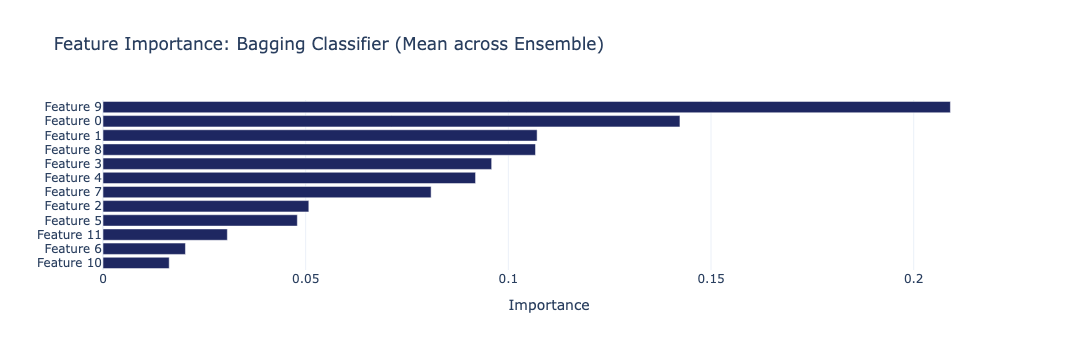

  Saved: outputs/bagging/feature_importance.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/bagging/feature_importance.html')

In [9]:
# Average feature importance across all trees in the ensemble
ensemble = best_bagging.named_steps["clf"]
importances = np.mean([est.feature_importances_ for est in ensemble.estimators_], axis=0)

# Build feature names that guaranteed match importances length
n_features = len(importances)
try:
    preprocessor = best_bagging.named_steps["prep"]
    raw_names = list(preprocessor.get_feature_names_out())
    # Strip sklearn prefixes like "num__" or "cat__"
    all_feature_names = [n.split("__", 1)[-1] if "__" in n else n for n in raw_names]
except Exception:
    all_feature_names = [f"Feature {i}" for i in range(n_features)]

# Truncate or pad if there's still a mismatch
if len(all_feature_names) != n_features:
    all_feature_names = [f"Feature {i}" for i in range(n_features)]

fig_imp = plot_feature_importance(importances, all_feature_names, MODEL_NAME, "Mean across Ensemble")
fig_imp.show()
save_chart(fig_imp, MODEL_SLUG, "feature_importance")

---
## 8. Out-of-Bag (OOB) Error Analysis

In [10]:
# Create bagging ensemble with OOB_score enabled
bag_oob = Pipeline([
    ("prep", prep_tree),
    ("clf", BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=ensemble.estimators_[0].max_depth,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        n_estimators=ensemble.n_estimators,
        max_samples=ensemble.max_samples,
        max_features=ensemble.max_features,
        oob_score=True,
        random_state=RANDOM_STATE,
    )),
])
bag_oob.fit(X_train, y_train)

oob_score = bag_oob.named_steps["clf"].oob_score_
print(f"OOB Score (accuracy): {oob_score:.4f}")
print(f"\nOOB error is an unbiased estimate of test error.")
print(f"It uses predictions from estimators that never saw each training sample.")
print(f"This avoids the need for a separate validation set.")

OOB Score (accuracy): 0.8479

OOB error is an unbiased estimate of test error.
It uses predictions from estimators that never saw each training sample.
This avoids the need for a separate validation set.


---
## 9. Ensemble Diversity and Prediction Variance

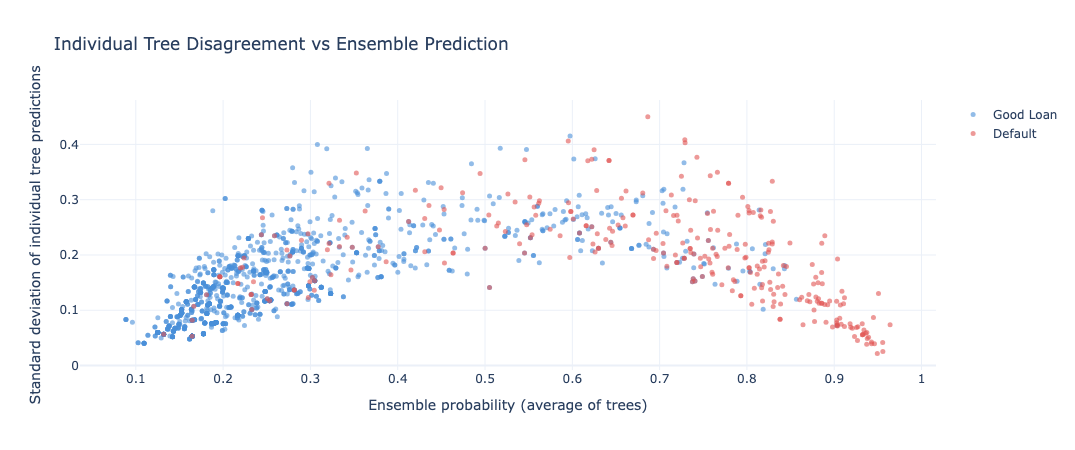

  Saved: outputs/bagging/tree_disagreement.html
Prediction variance statistics:
  Mean: 0.032035
  Std: 0.029376
  Max: 0.202771

  High variance = individual trees disagree (more uncertainty)
  Low variance = individual trees agree (more confidence)


In [12]:
# Analyze individual tree predictions and their agreement
prep_obj = best_bagging.named_steps["prep"]
X_test_prep = prep_obj.transform(X_test)
ensemble = best_bagging.named_steps["clf"]

# Get predictions from each tree — slice columns per estimator's feature subset
individual_probs = np.array([
    est.predict_proba(X_test_prep[:, features])[:, 1]
    for est, features in zip(ensemble.estimators_, ensemble.estimators_features_)
])

# Ensemble prediction is the average
ensemble_prob = individual_probs.mean(axis=0)

# Variance of predictions
pred_variance = individual_probs.var(axis=0)
pred_std = individual_probs.std(axis=0)

# Plot: relationship between ensemble variance and prediction
fig = go.Figure()
for label, color, name in [(0, COLORS["accent"], "Good Loan"), (1, COLORS["red"], "Default")]:
    mask = y_test == label
    fig.add_trace(go.Scatter(
        x=ensemble_prob[mask], y=pred_std[mask],
        mode="markers", name=name,
        marker=dict(color=color, size=5, opacity=0.6),
    ))
fig.update_layout(
    title="Individual Tree Disagreement vs Ensemble Prediction",
    xaxis_title="Ensemble probability (average of trees)",
    yaxis_title="Standard deviation of individual tree predictions",
    height=450, width=700,
)
fig.show()
save_chart(fig, MODEL_SLUG, "tree_disagreement")

print(f"Prediction variance statistics:")
print(f"  Mean: {pred_variance.mean():.6f}")
print(f"  Std: {pred_variance.std():.6f}")
print(f"  Max: {pred_variance.max():.6f}")
print(f"\n  High variance = individual trees disagree (more uncertainty)")
print(f"  Low variance = individual trees agree (more confidence)")

---
## 10. OOB Error by n_estimators

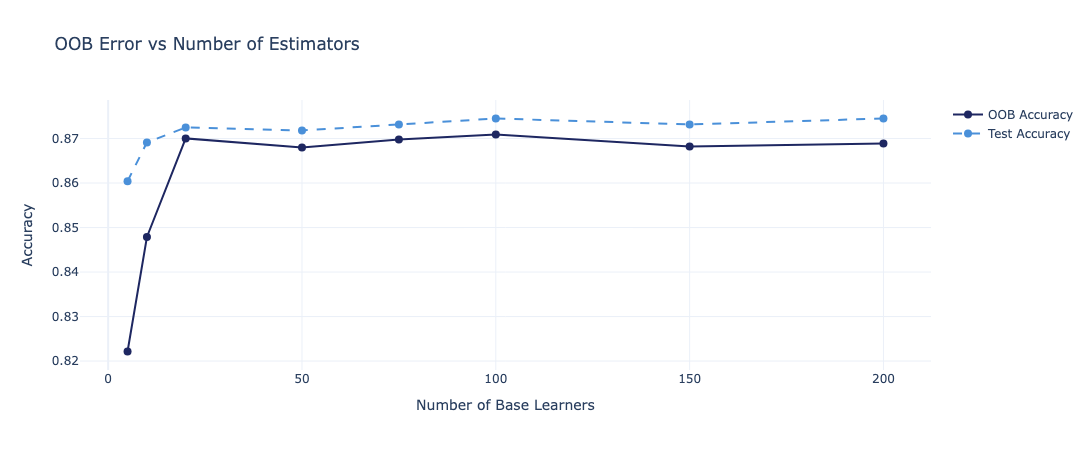

  Saved: outputs/bagging/oob_vs_estimators.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/bagging/oob_vs_estimators.html')

In [13]:
# Sweep n_estimators to show variance reduction over ensemble size
n_est_values = [5, 10, 20, 50, 75, 100, 150, 200]
oob_results = []

for n_est in n_est_values:
    bag_temp = Pipeline([
        ("prep", prep_tree),
        ("clf", BaggingClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=ensemble.estimators_[0].max_depth,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            n_estimators=n_est,
            max_samples=ensemble.max_samples,
            max_features=ensemble.max_features,
            oob_score=True,
            random_state=RANDOM_STATE,
        )),
    ])
    bag_temp.fit(X_train, y_train)
    oob_score = bag_temp.named_steps["clf"].oob_score_
    
    # Test score for comparison
    y_pred_temp = bag_temp.predict(X_test)
    test_score = accuracy_score(y_test, y_pred_temp)
    
    oob_results.append({
        "n_estimators": n_est,
        "oob_accuracy": oob_score,
        "test_accuracy": test_score,
    })

df_oob = pd.DataFrame(oob_results)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_oob["n_estimators"], y=df_oob["oob_accuracy"],
    name="OOB Accuracy", mode="lines+markers",
    line=dict(color=COLORS["navy"], width=2),
    marker=dict(size=8),
))
fig.add_trace(go.Scatter(
    x=df_oob["n_estimators"], y=df_oob["test_accuracy"],
    name="Test Accuracy", mode="lines+markers",
    line=dict(color=COLORS["accent"], width=2, dash="dash"),
    marker=dict(size=8),
))

fig.update_layout(
    title="OOB Error vs Number of Estimators",
    xaxis_title="Number of Base Learners",
    yaxis_title="Accuracy",
    height=450, width=700,
)
fig.show()
save_chart(fig, MODEL_SLUG, "oob_vs_estimators")

---
## 11. Diagnostic Charts

In [ ]:
# Generate and save all universal charts
charts = save_all_universal_charts(y_test, y_pred, y_score, MODEL_NAME, MODEL_SLUG)

for name, fig in charts.items():
    fig.show()


Saving universal charts for Bagging Classifier:
  Saved: outputs/bagging/roc_curve.html
  Saved: outputs/bagging/precision_recall_curve.html
  Saved: outputs/bagging/confusion_matrix.html
  Saved: outputs/bagging/threshold_sweep.html


---
## 12. Summary

### Where Bagging Sits on the Tradeoff Spectrum

Bagging tends toward the **moderate/balanced** end of the spectrum. While the individual decision trees in the ensemble use `class_weight="balanced"` (pushing toward higher recall), the averaging process smooths out extreme predictions, resulting in more conservative overall estimates. The ensemble is less aggressive than a single balanced tree but more aggressive than a linear model.

### Strengths for This Problem
- **Variance reduction:** Dramatically reduces the variance of high-variance base learners like decision trees
- **No increase in bias:** Averaging preserves the expected prediction, so bias does not increase
- **OOB error estimation:** Provides an unbiased estimate of test error without a separate validation set
- **Feature importance:** Still interpretable, as we can average feature importances across trees
- **Parallelizable:** Each bootstrap sample is independent, enabling easy parallelization
- **Works with any base estimator:** Can use decision trees, neural networks, or any other model
- **Robust to outliers:** The ensemble is more stable than individual trees

### Limitations for This Problem
- **Less powerful than Random Forest:** Does not introduce feature randomization, so variance reduction is less dramatic
- **Still limited by base estimator:** If the base learner is fundamentally poor, bagging cannot fix it
- **Does not reduce bias:** If the base learner is biased, that bias persists in the bagged ensemble
- **Correlated base learners:** Bootstrap samples are not independent, so trees are still correlated
- **Slower inference:** Must average predictions from M estimators instead of making a single prediction

### Key Takeaway
Bagging is the **bridge between single learners and advanced ensembles**. It reduces variance without the complexity of boosting or the feature randomization of Random Forest. For decision trees, Random Forest (which adds feature randomization) almost always outperforms Bagging, but Bagging is a useful baseline and works well with other base learners like neural networks or support vector machines.

---
*Notebook by Trinidad Cisneros — MIT Applied Data Science Program, April 2026*